# Part 5 — Guardrail Pipeline (CPU-Friendly)

This notebook demonstrates a 3-layer moderation pipeline:

1. **Input filter** using regex blocklists
2. **Model layer** using the saved Part 1 DistilBERT model
3. **Human review** for uncertain scores

It also reports:
- decision distribution by layer
- metrics on auto-actioned cases
- true label breakdown of the review queue
- sensitivity analysis for alternative review bands


In [1]:
!pip install -U transformers datasets scikit-learn pandas matplotlib seaborn tqdm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from collections import Counter

from pipeline import ModerationPipeline, input_filter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


c:\Users\maaaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DATA_PATH = r"C:\Users\maaaa\Desktop\RAI_assignment2\jigsaw-unintended-bias-train.csv"
MODEL_DIR = "./models_cpu_part1"

EVAL_SAMPLE_SIZE = 1000
LOW_THRESHOLD = 0.4
HIGH_THRESHOLD = 0.6

print({
    "EVAL_SAMPLE_SIZE": EVAL_SAMPLE_SIZE,
    "LOW_THRESHOLD": LOW_THRESHOLD,
    "HIGH_THRESHOLD": HIGH_THRESHOLD
})


{'EVAL_SAMPLE_SIZE': 1000, 'LOW_THRESHOLD': 0.4, 'HIGH_THRESHOLD': 0.6}


## Load a memory-safe evaluation subset


In [5]:
needed_cols = ["comment_text", "toxic"]

chunks = []
target_rows = 12000
taken = 0

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=needed_cols,
    dtype={"toxic": "float32"},
    chunksize=4000,
    low_memory=True
):
    chunk = chunk.dropna(subset=["comment_text", "toxic"]).copy()
    chunks.append(chunk)
    taken += len(chunk)
    if taken >= target_rows:
        break

df = pd.concat(chunks, ignore_index=True)
df["label"] = (df["toxic"] >= 0.5).astype("int8")

_, eval_df = train_test_split(
    df,
    test_size=min(EVAL_SAMPLE_SIZE, len(df) // 4),
    stratify=df["label"],
    random_state=SEED
)

eval_df = eval_df.reset_index(drop=True)

if len(eval_df) > EVAL_SAMPLE_SIZE:
    eval_df = eval_df.sample(EVAL_SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

print("Evaluation sample size:", len(eval_df))
eval_df.head()


Evaluation sample size: 1000


,comment_text,toxic,label
0,i'd like to commend the sheriff in montana fo...,0.0,0
1,Now that's a rebuttal I'd like to see in the...,0.0,0
2,This is a little bit glorious. Gosh I love Po...,0.0,0
3,"""Rockaway Beach"" is a fairly common place name...",0.0,0
4,"New TAX? Hell NO, we need new spending cuts.",0.4,0


## Initialize pipeline


In [6]:
pipe = ModerationPipeline(
    model_dir=MODEL_DIR,
    block_threshold=HIGH_THRESHOLD,
    allow_threshold=LOW_THRESHOLD,
    max_length=96
)
print("Pipeline loaded.")


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2735.62it/s]

Pipeline loaded.


## Run pipeline on 1,000 examples


In [7]:
decisions = []
for text in eval_df["comment_text"].tolist():
    decisions.append(pipe.predict(text))

decision_df = pd.DataFrame(decisions)
full_df = pd.concat([eval_df.reset_index(drop=True), decision_df.reset_index(drop=True)], axis=1)

full_df.head()


,comment_text,toxic,label,decision,layer,confidence
0,i'd like to commend the sheriff in montana fo...,0.0,0,allow,model,0.000686
1,Now that's a rebuttal I'd like to see in the...,0.0,0,allow,model,0.000492
2,This is a little bit glorious. Gosh I love Po...,0.0,0,allow,model,0.001823
3,"""Rockaway Beach"" is a fairly common place name...",0.0,0,allow,model,0.001260
4,"New TAX? Hell NO, we need new spending cuts.",0.4,0,allow,model,0.000529


## What fraction of decisions was handled by each layer / decision?


In [8]:
layer_counts = full_df["layer"].value_counts(dropna=False)
decision_counts = full_df["decision"].value_counts(dropna=False)

print("Layer counts:")
print(layer_counts)

print("\nDecision counts:")
print(decision_counts)


Layer counts:
layer
model    1000
Name: count, dtype: int64

Decision counts:
decision
allow     952
block      47
review      1
Name: count, dtype: int64


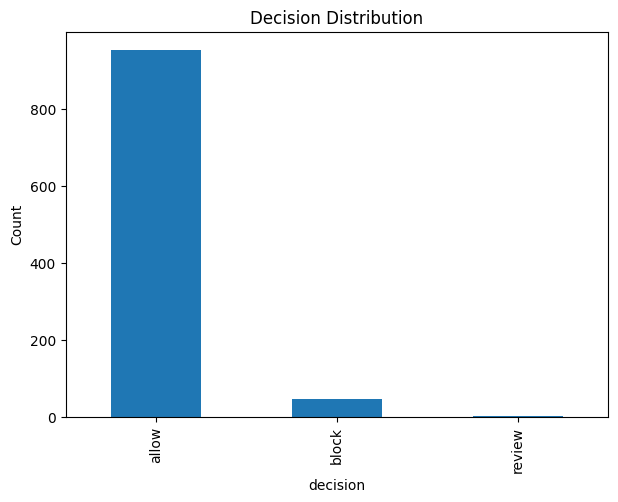

In [9]:
plt.figure(figsize=(7, 5))
decision_counts.plot(kind="bar")
plt.title("Decision Distribution")
plt.ylabel("Count")
plt.show()


## Input filter category distribution


In [10]:
input_filter_df = full_df[full_df["layer"] == "input_filter"].copy()

if len(input_filter_df) > 0:
    cat_counts = input_filter_df["category"].value_counts()
    print(cat_counts)

    plt.figure(figsize=(8, 5))
    cat_counts.plot(kind="bar")
    plt.title("Input Filter Blocks by Category")
    plt.ylabel("Count")
    plt.show()
else:
    print("No comments were blocked by the input filter in this sample.")


No comments were blocked by the input filter in this sample.


## Auto-actioned subset (model confident block/allow only)
Exclude review items.


In [11]:
auto_df = full_df[
    (full_df["layer"] == "model") &
    (full_df["decision"].isin(["block", "allow"]))
].copy()

if len(auto_df) > 0:
    auto_df["pred_binary"] = (auto_df["decision"] == "block").astype(int)

    auto_f1 = f1_score(auto_df["label"], auto_df["pred_binary"], average="macro")
    auto_precision = precision_score(auto_df["label"], auto_df["pred_binary"], zero_division=0)
    auto_recall = recall_score(auto_df["label"], auto_df["pred_binary"], zero_division=0)

    print("Auto-actioned subset size:", len(auto_df))
    print("F1 (macro):", auto_f1)
    print("Precision:", auto_precision)
    print("Recall:", auto_recall)
else:
    print("No auto-actioned model decisions found.")


Auto-actioned subset size: 999
F1 (macro): 0.7565591747217935
Precision: 0.5957446808510638
Recall: 0.49122807017543857


## Review queue subset breakdown


In [12]:
review_df = full_df[full_df["decision"] == "review"].copy()

if len(review_df) > 0:
    print("Review queue size:", len(review_df))
    print("Actual label breakdown:")
    print(review_df["label"].value_counts())
    print("Toxic rate in review queue:", review_df["label"].mean())
else:
    print("No review queue items found.")


Review queue size: 1
Actual label breakdown:
label
1    1
Name: count, dtype: int64
Toxic rate in review queue: 1.0


## Sensitivity analysis for different review bands
We compare:
- 0.45–0.55
- 0.40–0.60
- 0.30–0.70


In [13]:
def run_band_analysis(low, high, eval_frame):
    temp_pipe = ModerationPipeline(
        model_dir=MODEL_DIR,
        block_threshold=high,
        allow_threshold=low,
        max_length=96
    )

    rows = []
    for text in eval_frame["comment_text"].tolist():
        rows.append(temp_pipe.predict(text))

    temp_dec = pd.DataFrame(rows)
    temp_full = pd.concat([eval_frame.reset_index(drop=True), temp_dec.reset_index(drop=True)], axis=1)

    auto_temp = temp_full[
        (temp_full["layer"] == "model") &
        (temp_full["decision"].isin(["block", "allow"]))
    ].copy()

    review_temp = temp_full[temp_full["decision"] == "review"].copy()

    if len(auto_temp) > 0:
        auto_temp["pred_binary"] = (auto_temp["decision"] == "block").astype(int)
        auto_f1 = f1_score(auto_temp["label"], auto_temp["pred_binary"], average="macro")
    else:
        auto_f1 = np.nan

    return {
        "band": f"{low:.2f}-{high:.2f}",
        "review_count": len(review_temp),
        "review_fraction": len(review_temp) / len(temp_full),
        "auto_action_count": len(auto_temp),
        "auto_action_fraction": len(auto_temp) / len(temp_full),
        "auto_action_f1": auto_f1
    }

band_results = pd.DataFrame([
    run_band_analysis(0.45, 0.55, eval_df),
    run_band_analysis(0.40, 0.60, eval_df),
    run_band_analysis(0.30, 0.70, eval_df),
])

band_results


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 942.67it/s]


,band,review_count,review_fraction,auto_action_count,auto_action_fraction,auto_action_f1
0,0.45-0.55,0,0.000,1000,1.000,0.760913
1,0.40-0.60,1,0.001,999,0.999,0.756559
2,0.30-0.70,4,0.004,996,0.996,0.765329


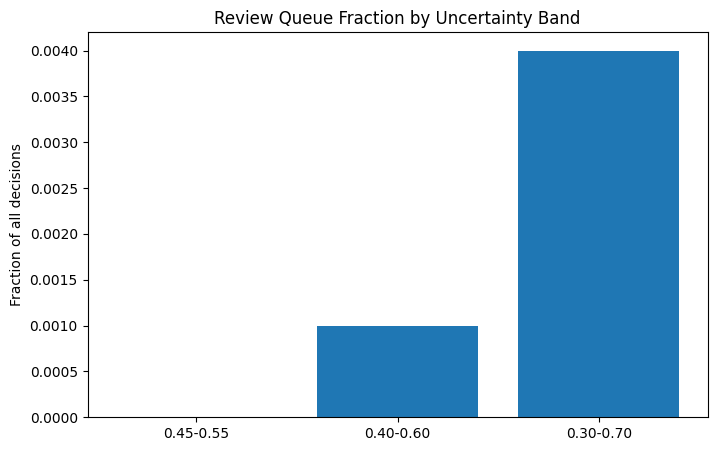

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(band_results["band"], band_results["review_fraction"])
plt.title("Review Queue Fraction by Uncertainty Band")
plt.ylabel("Fraction of all decisions")
plt.show()


## Markdown answer for your notebook

Paste and adapt this after you see your actual numbers:

**Part 5 Discussion**

The 0.4–0.6 uncertainty band creates a balance between automation and caution. A narrower band such as 0.45–0.55 reduces the review workload, but it also increases the share of automatic decisions made at lower certainty. A wider band such as 0.3–0.7 increases human review volume and can improve confidence in automated actions, but at a higher operational cost.

The best choice depends on the platform’s staffing and harm tolerance. In general, if the review queue becomes too large, the narrower band may be operationally necessary. If the platform prioritizes caution for borderline content, a wider band is safer. The sensitivity analysis above provides the actual trade-off numbers for this dataset and model.
